Application of least squares for the regression problem.    
 Using the provided laptop price dataset (Link), apply Least squares method to predict the      
 laptop price using the laptop features.        
 1. Code lease squares method.      
 2. Identify and mention the input features (X) and target variable (Y).        
 3. Print the equation of the fitted hyperplane     
 4. Print the Mean Squared Error (MSE)     
 5. Interpret the fitted hyperplane and write about your observation of the relationship        
 between the input variables and output      

In [1]:
import pandas as pd

In [ ]:
# Load dataset from file. Current code expects the file under same location/folder as that of this Notebook file.
df = pd.read_csv("laptop_price_small.csv")

df.head()

,laptop_ID,Inches,RAM_in_GB,Weight_in_KG,Price_euros
0,1,13.3,8,1.37,1339.69
1,2,13.3,8,1.34,898.94
2,3,15.6,8,1.86,575.00
3,4,15.4,16,1.83,2537.45
4,5,13.3,8,1.37,1803.60


In [35]:
# X represents the feature list
X = df[['Inches', 'RAM_in_GB', 'Weight_in_KG']]
# Y represents the outcome variable
Y = df['Price_euros']

In [6]:
%pip install scikit-learn

  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.9 MB 9.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.7/8.9 MB 9.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.9 MB 10.2 MB/s eta 0:00:01
   ------------------------------------- -- 8.4/8.9 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 9.2 MB/s  0:00:01
Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl (38.7 MB)

   ---------------------------------------- 0/4 [threadpoolctl]
   ---------------------------------------- 0/4 [threadpoolctl]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   -------

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [8]:
# Fit the Linear Regression model (Least Squares Method)
model = LinearRegression()
model.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Predict and calculate MSE
Y_pred = model.predict(X)
mse_value = mean_squared_error(Y, Y_pred)

In [17]:
print(f"MSE: {round(mse_value,2)}")

MSE: 212420.68


In [18]:
intercept = round(model.intercept_,2)
features = ['Inches', 'RAM_in_GB', 'Weight_in_KG']
coefficients = model.coef_

print(f"Model Intercept: {intercept}")
print(f"Model Coefficients {features}: {coefficients}")

Model Intercept: 1220.33
Model Coefficients ['Inches', 'RAM_in_GB', 'Weight_in_KG']: [-70.1057959  104.93841511  37.53828669]


In [ ]:
equation_parts = [f"{intercept:.2f}"]

for feature, coef in zip(features, coefficients):
    sign = "+" if coef >= 0 else "-"
    equation_parts.append(f"{sign} {abs(coef):.2f} * {feature}")

# Combine the parts
fitted_equation = "Price_euros = " + " ".join(equation_parts)

print(fitted_equation)

Price_euros = 1220.33 - 70.11 * Inches + 104.94 * RAM_in_GB + 37.54 * Weight_in_KG


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

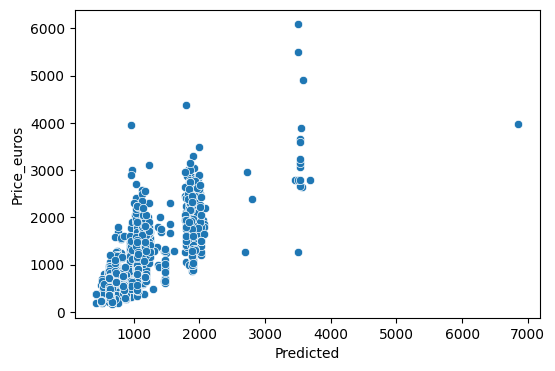

In [ ]:
# Figure to plot Predicted vs Actual Price
plt.figure(figsize=(6,4))

df['Predicted'] = Y_pred

sns.scatterplot(
    data = df,
    x = 'Predicted',
    y = 'Price_euros'
)

plt.xlabel = "Predicted Price"
plt.ylabel = "Actual Price"
plt.title = "Actual Price vs Predicted Price"
plt.show()

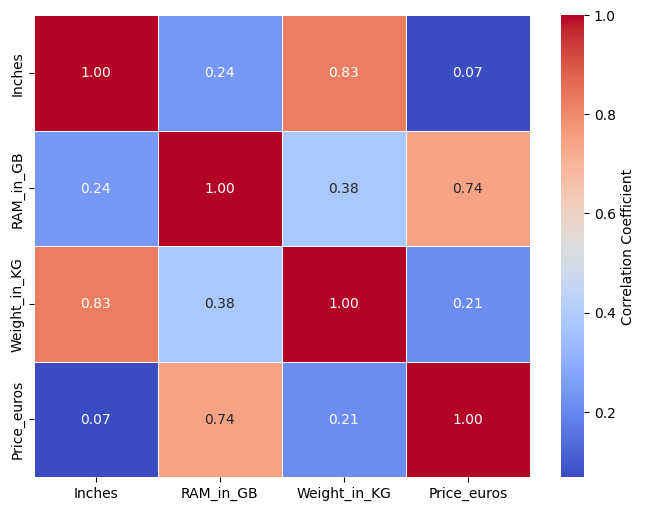

In [36]:
# Plot to visualize the co-relation matrix to interpret the influence of different feature on outcome variable
correlation_matrix = df[['Inches', 'RAM_in_GB', 'Weight_in_KG', 'Price_euros']].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the correlation values on the map
    fmt=".2f",           # Format the values to 2 decimal places
    cmap='coolwarm',     # Color map: shows strong positive (red/warm) and negative (blue/cool) correlations
    linewidths=.5,       # Add lines between cells for clarity
    cbar_kws={'label': 'Correlation Coefficient'} # Label for the color bar
)

plt.title = 'Correlation Heatmap of Features and Price'
plt.show()

### Interpretation and Observations

As represented from co-efficients for different features:
* RAM_in_GB: Overall price increases by 104.94 euros for every 1 unit (here 1 GB) increase. Which represents strongest co-relation in the current dataset context to outcome (here Price_euros).
* Weight_in_KG: Overall price increases by 37.54 euros for every 1 unit (here 1 KG) increase. Which represents strong co-relation between feature and outcome (here Price_euros).
* Inches: Price decreases by 70.11 euros for every 1 unit (here screen size in inches) increase. Which represents strong negative co-relation between feature and outcome (here Price_euros).